# Mean-centred analysis of spectral data

This example is based on the [MNE tutorial on common spatial patterns](https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html) (CSP). We will examine spectral power in a motor imagery dataset in which a participant engaged in hands or feet motor imagery.

## Loading raw data

In [1]:
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
import numpy as np
import mne_plsc

raw_fnames = eegbci.load_data(subjects=1, runs=[6, 10, 14], update_path=True)
raw = concatenate_raws([read_raw_edf(f, preload=True) for f in raw_fnames])
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage("standard_1005")
raw.set_montage(montage)
raw.annotations.rename(dict(T1="hands", T2="feet"))  # as documented on PhysioNet
raw = raw.set_eeg_reference(projection=True)

Extracting EDF parameters from C:\Users\isaac\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\isaac\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\isaac\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


## Extracting epochs

We will extract epochs from 1 second to 4 seconds after trial onset, since the early data is less likely to contain signal of interest.

In [2]:
# Apply band-pass filter
# raw.filter(7.0, 30.0, fir_design="firwin", skip_by_annotation="edge")

picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
epochs = Epochs(
    raw,
    event_id=["hands", "feet"],
    tmin=1,
    tmax=4,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True,
)

Used Annotations descriptions: [np.str_('T0'), np.str_('feet'), np.str_('hands')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
45 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 45 events and 481 original time points ...
0 bad epochs dropped


## Computing spectral power

Next, we will compute spectral power up to 40 Hz and decibel transform it. The decibel transform normalizes the spectral power estimates and improves the performance of the model on this dataset.

In [3]:
spec = epochs.compute_psd(fmax=40)
spec._data = 10*np.log10(spec._data) # decibel transform

    Using multitaper spectrum estimation with 7 DPSS windows


## Fitting and evaluating mean-centred PLS model

Next, we will extract the labels associated with each epoch and use them to fit the model.

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: xlabel='Frequecy (Hz)', ylabel='Salience'>,
        <Axes: ylabel='Brain score'>], dtype=object))

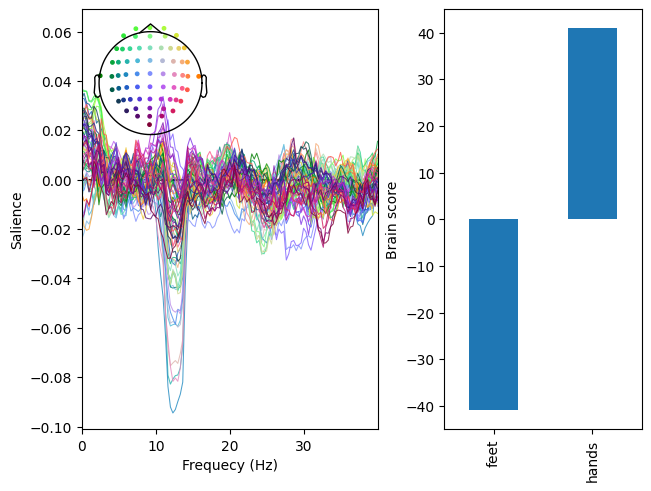

In [4]:
labels = mne_plsc.utils.get_epoch_labels(spec)
res = mne_plsc.fit_mc(data=spec,
                      between=labels,
                      random_state=123)
res.plot_lv(0)

Examining the brain saliences on the left, we can see that the model identifies a pattern of reduced power between approximately 10 and 15 Hz. Examining the brain scores on the right, we can see that this pattern is more strongly expressed for hands relative to feet motor imagery. Thus, spectral power between 10 and 15 Hz appears to be lower for hands relative to feet. Permutation testing shows that this pattern is significant:

In [9]:
res.permute(500)
print(res.summary())

Permuting: 100%|█████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 131.19it/s]

   LV index  singular value  variance explained   p value
0         0       57.810217                 1.0  0.001996
1         1        0.000000                 0.0       NaN


## Cluster analysis

To chracterize the spectral and spatial distribution of this pattern, we can use bootstrap resampling to estimate the $z$ scores of the brain saliences and cluster the reliable saliences. This yields a single cluster:

In [14]:
res.bootstrap(500)
res.add_adjacency()
res.cluster(threshold=5)

Resampling: 100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 201.34it/s]

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 64


Clustering z-scores
Computing clusters for lv_idx 0...
1 clusters


We can plot this cluster to not only confirm that it corresponds to the 10--15 Hz range we identified earlier, but also to examine its spatial distribution.

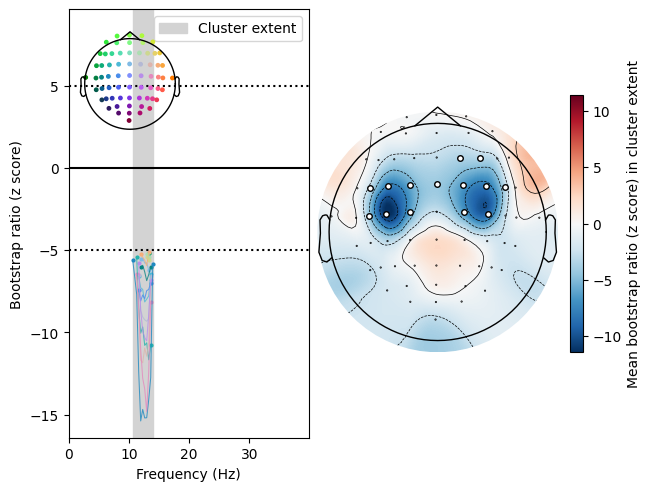

In [15]:
res.plot_cluster(lv_idx=0, cluster_idx=0, highlight='extent')

This bilateral pair of sites overlaps with the spatial patterns identified by CSP in the MNE tutorial.